# The Linear Regression Engine
## Dataset: Artisan Cheese Fermentation Time Prediction

**Objective:** Build a complete linear regression pipeline from first principles, covering Ordinary Least Squares (OLS), Ridge (L2), Lasso (L1), and Elastic Net regularization.

**What you will learn:**
- How OLS finds the best-fit line using the closed-form Normal Equation
- How Gradient Descent iteratively minimizes the cost function
- Why regularization prevents overfitting and what L1 vs L2 actually do geometrically
- How to choose the right regularization strength using cross-validation
- How to properly evaluate regression models and interpret residuals

**Dataset:** Predicting the optimal fermentation time (in hours) of artisan cheese based on biochemical and environmental factors. This is a synthetic dataset designed to mimic real-world fermentation science.

---
## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = {'ols': '#2196F3', 'ridge': '#4CAF50', 'lasso': '#FF9800', 'elastic': '#9C27B0'}

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load and Explore the Dataset

The dataset contains 2,000 synthetic observations of artisan cheese fermentation. Each row represents one batch of cheese with its measured biochemical and environmental conditions, and the resulting optimal fermentation time.

In [2]:
df = pd.read_csv('../data/artisan_cheese_fermentation_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 9)


,milk_fat_percentage,starter_culture_ph,ambient_temperature,fermentation_humidity,salt_concentration,curd_cut_size,aging_room_airflow,bacterial_strain_type,optimal_fermentation_time
0,7.53,6.39,22.9,75.9,2.18,1.89,0.67,1,49.5
1,5.35,5.36,16.4,64.2,3.19,1.86,0.49,2,57.1
2,8.08,6.68,25.3,79.9,1.33,0.75,0.18,3,38.9
3,7.03,5.89,14.3,65.5,0.58,0.38,1.19,2,40.6
4,3.11,4.50,19.7,62.1,2.83,0.97,0.29,1,34.7


In [3]:
print('Dataset Summary Statistics:')
df.describe().round(2)

Dataset Summary Statistics:


,milk_fat_percentage,starter_culture_ph,ambient_temperature,fermentation_humidity,salt_concentration,curd_cut_size,aging_room_airflow,bacterial_strain_type,optimal_fermentation_time
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,5.77,5.48,18.79,77.47,2.01,1.40,0.64,1.56,39.68
std,1.89,0.75,5.12,10.10,0.86,0.63,0.31,1.12,11.40
min,2.50,4.20,10.00,60.00,0.50,0.30,0.10,0.00,8.00
25%,4.09,4.84,14.30,68.90,1.25,0.85,0.37,1.00,31.80
50%,5.72,5.49,18.70,77.60,2.04,1.41,0.64,2.00,39.90
75%,7.45,6.14,23.20,85.93,2.73,1.95,0.91,3.00,47.60
max,9.00,6.80,28.00,95.00,3.50,2.50,1.20,3.00,73.50


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTarget variable range: {df.optimal_fermentation_time.min():.1f} to {df.optimal_fermentation_time.max():.1f} hours')

Missing values per column:
milk_fat_percentage          0
starter_culture_ph           0
ambient_temperature          0
fermentation_humidity        0
salt_concentration           0
curd_cut_size                0
aging_room_airflow           0
bacterial_strain_type        0
optimal_fermentation_time    0
dtype: int64

Target variable range: 8.0 to 73.5 hours


### 2.1 Exploratory Data Analysis (EDA)

Before building any model, we must understand the data. We look at the distribution of the target variable and the correlation between features and the target.

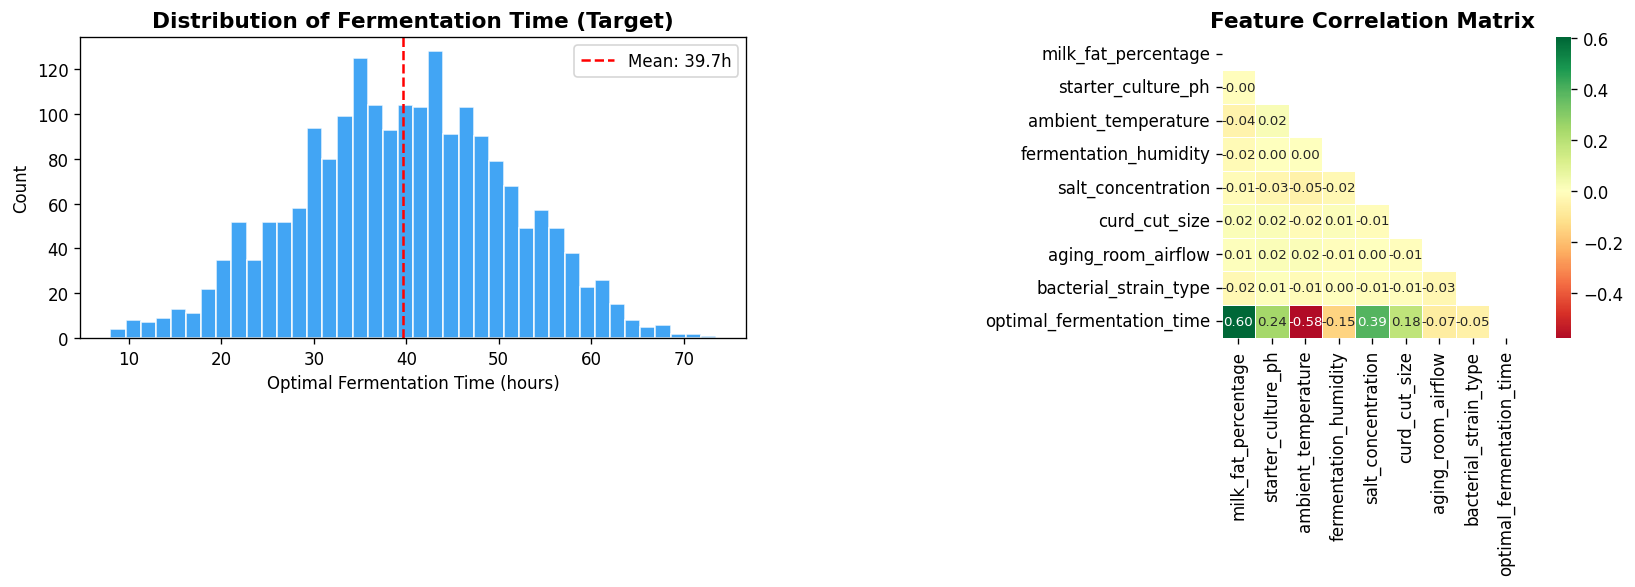

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
axes[0].hist(df['optimal_fermentation_time'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Fermentation Time (Target)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Optimal Fermentation Time (hours)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['optimal_fermentation_time'].mean(), color='red', linestyle='--', label=f'Mean: {df["optimal_fermentation_time"].mean():.1f}h')
axes[0].legend()

# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[1], square=True, linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/proj1_cheese_eda.png', bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing

### 3.1 Why Preprocessing Matters

Linear regression models are sensitive to the scale of features. If `ring_oscillator_speed` is in the hundreds of MHz and `vdd_core` is around 0.9V, the model will incorrectly assign more importance to the larger-scale feature. We use `StandardScaler` to normalize all numeric features to zero mean and unit variance.

**Critical: We fit the scaler ONLY on the training data, then transform both train and test sets.** Fitting on the full dataset would cause data leakage — the model would have indirect knowledge of the test set distribution.

In [6]:
# Define features and target
TARGET = 'optimal_fermentation_time'
NUMERIC_FEATURES = ['milk_fat_percentage', 'starter_culture_ph', 'ambient_temperature',
                    'fermentation_humidity', 'salt_concentration', 'curd_cut_size', 'aging_room_airflow']
CATEGORICAL_FEATURES = ['bacterial_strain_type']

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# Train/Validation/Test split: 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')

# Preprocessing pipeline: scale numerics, one-hot encode categoricals
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), CATEGORICAL_FEATURES)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

print(f'\nProcessed feature matrix shape: {X_train_proc.shape}')

Training set:   1400 samples
Validation set: 300 samples
Test set:       300 samples

Processed feature matrix shape: (1400, 10)


---
## 4. Ordinary Least Squares (OLS) — From Scratch

### 4.1 The Mathematics

OLS finds the coefficients **w** that minimize the Mean Squared Error (MSE) cost function:

$$J(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$$

**Closed-Form Solution (Normal Equation):** Setting the gradient to zero gives the exact solution:

$$\mathbf{w}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

This is computationally efficient for small datasets but becomes expensive for very large feature matrices.

In [7]:
class OLSScratch:
    """Ordinary Least Squares via the Normal Equation."""
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Add bias column
        X_b = np.c_[np.ones(X.shape[0]), X]
        # Normal equation: w = (X^T X)^-1 X^T y
        self.theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        self.bias = self.theta[0]
        self.weights = self.theta[1:]
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

ols_scratch = OLSScratch()
ols_scratch.fit(X_train_proc, y_train.values)
y_pred_ols = ols_scratch.predict(X_val_proc)

mse = mean_squared_error(y_val, y_pred_ols)
r2  = r2_score(y_val, y_pred_ols)
print(f'OLS (Normal Equation) — Validation MSE: {mse:.3f} | RMSE: {np.sqrt(mse):.3f} | R²: {r2:.4f}')

OLS (Normal Equation) — Validation MSE: 6.301 | RMSE: 2.510 | R²: 0.9498


### 4.2 Gradient Descent OLS

Gradient Descent is an iterative optimization algorithm. Instead of solving for the exact minimum analytically, it takes small steps in the direction of the steepest descent of the cost function. The update rule is:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \nabla J(\mathbf{w})$$

where $\alpha$ is the **learning rate** — a hyperparameter controlling the step size. Too large and it overshoots; too small and it converges slowly.

OLS (Gradient Descent) — Validation MSE: 6.301 | RMSE: 2.510 | R²: 0.9498


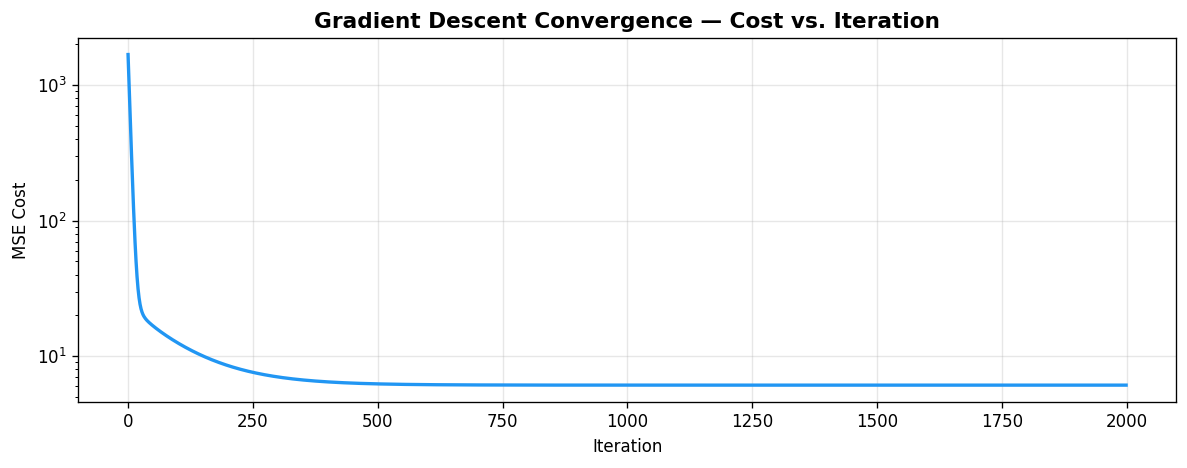

In [8]:
class OLSGradientDescent:
    """Ordinary Least Squares via Batch Gradient Descent."""
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.cost_history = []
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iter):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            # Gradients
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)
            # Update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db
            # Track cost
            cost = np.mean(error ** 2)
            self.cost_history.append(cost)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

ols_gd = OLSGradientDescent(learning_rate=0.05, n_iterations=2000)
ols_gd.fit(X_train_proc, y_train.values)
y_pred_gd = ols_gd.predict(X_val_proc)

mse_gd = mean_squared_error(y_val, y_pred_gd)
r2_gd  = r2_score(y_val, y_pred_gd)
print(f'OLS (Gradient Descent) — Validation MSE: {mse_gd:.3f} | RMSE: {np.sqrt(mse_gd):.3f} | R²: {r2_gd:.4f}')

# Plot convergence
plt.figure(figsize=(10, 4))
plt.plot(ols_gd.cost_history, color='#2196F3', linewidth=2)
plt.title('Gradient Descent Convergence — Cost vs. Iteration', fontsize=13, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('MSE Cost')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/proj1_cheese_gd_convergence.png', bbox_inches='tight')
plt.show()

---
## 5. Regularization: Ridge, Lasso, and Elastic Net

### Why Regularization?

OLS minimizes only the training error. When a model has many features or correlated features, it can overfit — learning the noise in the training data rather than the true signal. Regularization adds a **penalty term** to the cost function that discourages large coefficients.

| Method | Penalty Added to MSE | Effect |
|:---|:---|:---|
| **Ridge (L2)** | $\alpha \sum w_i^2$ | Shrinks all coefficients toward zero, never exactly zero |
| **Lasso (L1)** | $\alpha \sum |w_i|$ | Drives some coefficients to exactly zero (feature selection) |
| **Elastic Net** | $\alpha_1 \sum |w_i| + \alpha_2 \sum w_i^2$ | Combines both — sparse and stable |

In [9]:
# Train all three regularized models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

models = {'Ridge (L2)': ridge, 'Lasso (L1)': lasso, 'Elastic Net': elastic}
results = {}

for name, model in models.items():
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_val_proc)
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    r2  = r2_score(y_val, y_pred)
    results[name] = {'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': mae, 'R2': r2}
    print(f'{name:15s} — RMSE: {np.sqrt(mse):.3f} | MAE: {mae:.3f} | R²: {r2:.4f}')

# Add OLS baseline
ols_sklearn = LinearRegression()
ols_sklearn.fit(X_train_proc, y_train)
y_pred_ols_sk = ols_sklearn.predict(X_val_proc)
mse_sk = mean_squared_error(y_val, y_pred_ols_sk)
results['OLS (sklearn)'] = {'MSE': mse_sk, 'RMSE': np.sqrt(mse_sk),
                             'MAE': mean_absolute_error(y_val, y_pred_ols_sk),
                             'R2': r2_score(y_val, y_pred_ols_sk)}
print(f'{"OLS (sklearn)":15s} — RMSE: {np.sqrt(mse_sk):.3f} | MAE: {mean_absolute_error(y_val, y_pred_ols_sk):.3f} | R²: {r2_score(y_val, y_pred_ols_sk):.4f}')

Ridge (L2)      — RMSE: 2.510 | MAE: 2.005 | R²: 0.9498
Lasso (L1)      — RMSE: 2.550 | MAE: 2.011 | R²: 0.9482
Elastic Net     — RMSE: 2.597 | MAE: 2.052 | R²: 0.9463
OLS (sklearn)   — RMSE: 2.510 | MAE: 2.005 | R²: 0.9498


### 5.1 Coefficient Shrinkage Paths

As the regularization strength (alpha) increases, coefficients are penalized more heavily and shrink toward zero. The key difference: Ridge shrinks them gradually but never to zero, while Lasso can eliminate features entirely.

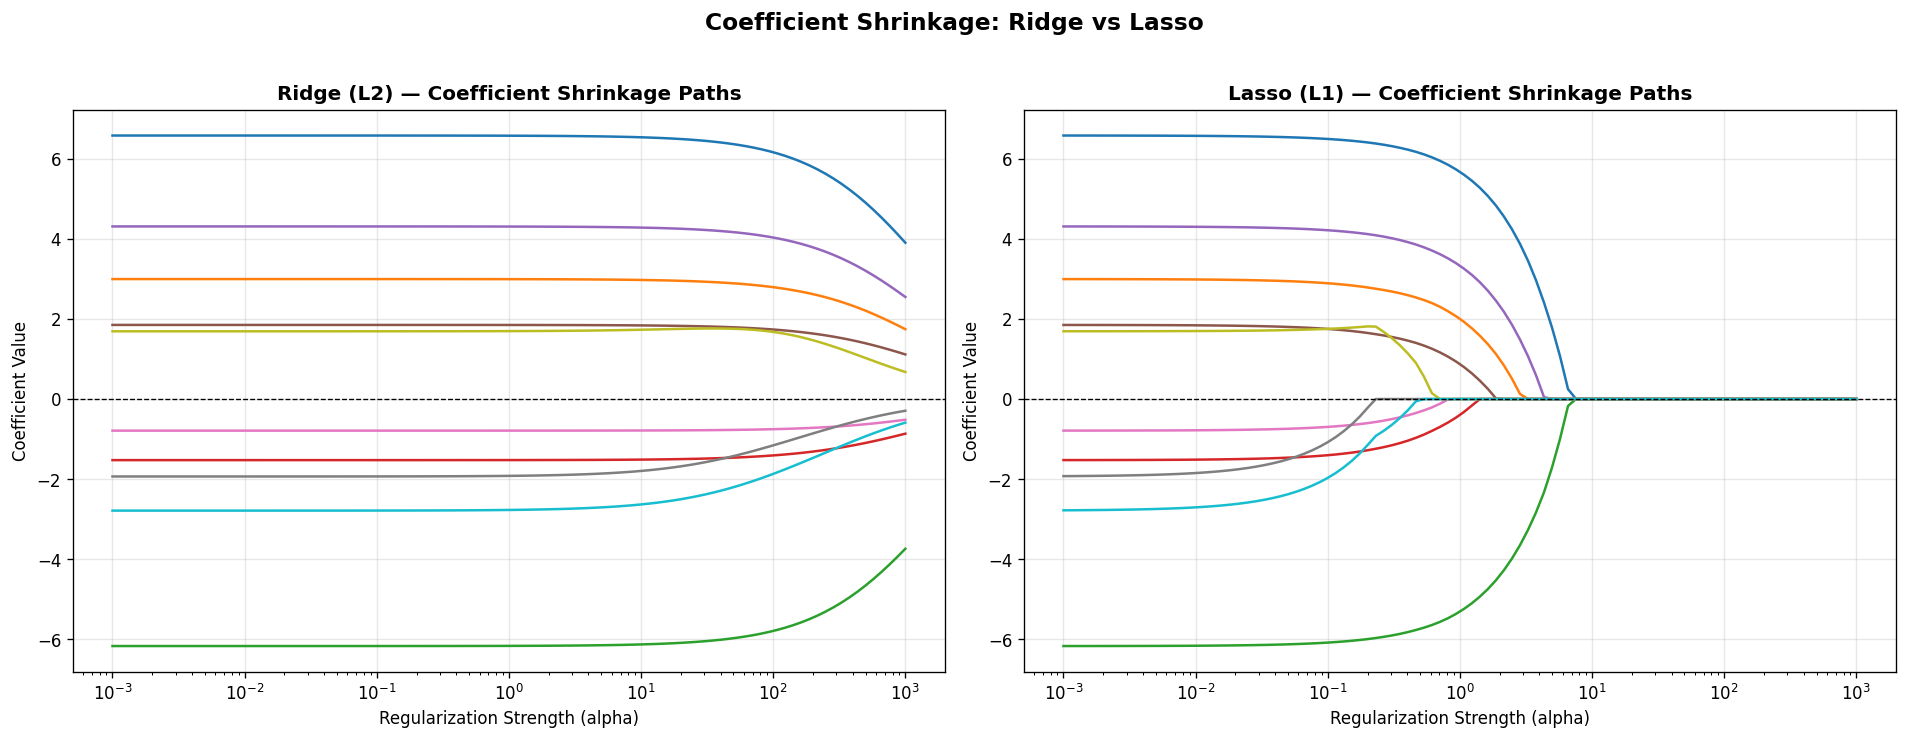

Key insight: Lasso drives coefficients to exactly zero (feature selection), Ridge only shrinks them.


In [10]:
alphas = np.logspace(-3, 3, 100)
feature_names = NUMERIC_FEATURES + [f'strain_{i}' for i in range(3)]

ridge_coefs = [Ridge(alpha=a).fit(X_train_proc, y_train).coef_ for a in alphas]
lasso_coefs = [Lasso(alpha=a, max_iter=5000).fit(X_train_proc, y_train).coef_ for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, coef in enumerate(np.array(ridge_coefs).T):
    axes[0].plot(alphas, coef, linewidth=1.5)
axes[0].set_xscale('log')
axes[0].set_title('Ridge (L2) — Coefficient Shrinkage Paths', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Regularization Strength (alpha)')
axes[0].set_ylabel('Coefficient Value')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

for i, coef in enumerate(np.array(lasso_coefs).T):
    axes[1].plot(alphas, coef, linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_title('Lasso (L1) — Coefficient Shrinkage Paths', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Regularization Strength (alpha)')
axes[1].set_ylabel('Coefficient Value')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Coefficient Shrinkage: Ridge vs Lasso', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/proj1_cheese_coefficient_paths.png', bbox_inches='tight')
plt.show()
print('Key insight: Lasso drives coefficients to exactly zero (feature selection), Ridge only shrinks them.')

---
## 6. Hyperparameter Tuning — Finding the Best Alpha

The regularization strength `alpha` is a hyperparameter — it is not learned from data, it must be chosen by us. We use **k-fold cross-validation** to find the alpha that minimizes validation error without touching the test set.

In [11]:
from sklearn.linear_model import RidgeCV, LassoCV

alphas_cv = np.logspace(-3, 2, 50)

ridge_cv = RidgeCV(alphas=alphas_cv, cv=5)
ridge_cv.fit(X_train_proc, y_train)
print(f'Best Ridge alpha (5-fold CV): {ridge_cv.alpha_:.4f}')

lasso_cv = LassoCV(alphas=alphas_cv, cv=5, max_iter=10000)
lasso_cv.fit(X_train_proc, y_train)
print(f'Best Lasso alpha (5-fold CV): {lasso_cv.alpha_:.4f}')
print(f'Lasso non-zero coefficients: {np.sum(lasso_cv.coef_ != 0)} out of {len(lasso_cv.coef_)}')

Best Ridge alpha (5-fold CV): 1.1514
Best Lasso alpha (5-fold CV): 0.0010
Lasso non-zero coefficients: 10 out of 10


---
## 7. Final Evaluation on the Test Set

We evaluate all models on the held-out test set only once — after all hyperparameter decisions are finalized. This gives an unbiased estimate of real-world performance.

In [12]:
final_models = {
    'OLS (Normal Eq.)': ols_scratch,
    'OLS (sklearn)':    ols_sklearn,
    'Ridge (best alpha)': ridge_cv,
    'Lasso (best alpha)': lasso_cv,
    'Elastic Net':        elastic,
}

print(f'{"Model":<22} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 50)
for name, model in final_models.items():
    if hasattr(model, 'predict'):
        y_pred = model.predict(X_test_proc)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)
        print(f'{name:<22} {rmse:>8.3f} {mae:>8.3f} {r2:>8.4f}')

Model                      RMSE      MAE       R2
--------------------------------------------------
OLS (Normal Eq.)          2.441    1.931   0.9535
OLS (sklearn)             2.441    1.931   0.9535
Ridge (best alpha)        2.442    1.931   0.9535
Lasso (best alpha)        2.442    1.931   0.9535
Elastic Net               2.604    2.057   0.9471


### 7.1 Training Data Fit vs Test Data Fit

A model that performs well on training data but poorly on test data is **overfitting** — it has memorized the training set rather than learning the underlying pattern. Below we plot the actual vs predicted values for both training and test sets side by side to visually confirm that our best model (Ridge with CV-optimized alpha) generalizes well.

In [ ]:
# Training vs Test fit for the best model (Ridge CV)
y_train_pred = ridge_cv.predict(X_train_proc)
y_test_pred  = ridge_cv.predict(X_test_proc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Data Fit
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color='#2196F3', s=15, label=f'Train R² = {r2_score(y_train, y_train_pred):.4f}')
lims_tr = [min(y_train.min(), y_train_pred.min()), max(y_train.max(), y_train_pred.max())]
axes[0].plot(lims_tr, lims_tr, 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_title('Training Data Fit', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Fermentation Time (h)')
axes[0].set_ylabel('Predicted Fermentation Time (h)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Test Data Fit
axes[1].scatter(y_test, y_test_pred, alpha=0.3, color='#4CAF50', s=15, label=f'Test R² = {r2_score(y_test, y_test_pred):.4f}')
lims_te = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[1].plot(lims_te, lims_te, 'r--', linewidth=1.5, label='Perfect Fit')
axes[1].set_title('Test Data Fit', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Fermentation Time (h)')
axes[1].set_ylabel('Predicted Fermentation Time (h)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ridge Regression — Training vs Test Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/proj1_cheese_train_vs_test.png', bbox_inches='tight', dpi=150)
plt.show()

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f'Training RMSE: {train_rmse:.3f} | Test RMSE: {test_rmse:.3f}')
print(f'Training R²:   {r2_score(y_train, y_train_pred):.4f} | Test R²:   {r2_score(y_test, y_test_pred):.4f}')
print(f'\nGap: {abs(r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)):.4f} — {"Healthy generalization" if abs(r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)) < 0.05 else "Possible overfitting"}')

### 7.2 Residual Analysis

A well-fitted regression model should have residuals (prediction errors) that are randomly distributed around zero with no pattern. Patterns in residuals indicate that the model is missing some structure in the data.

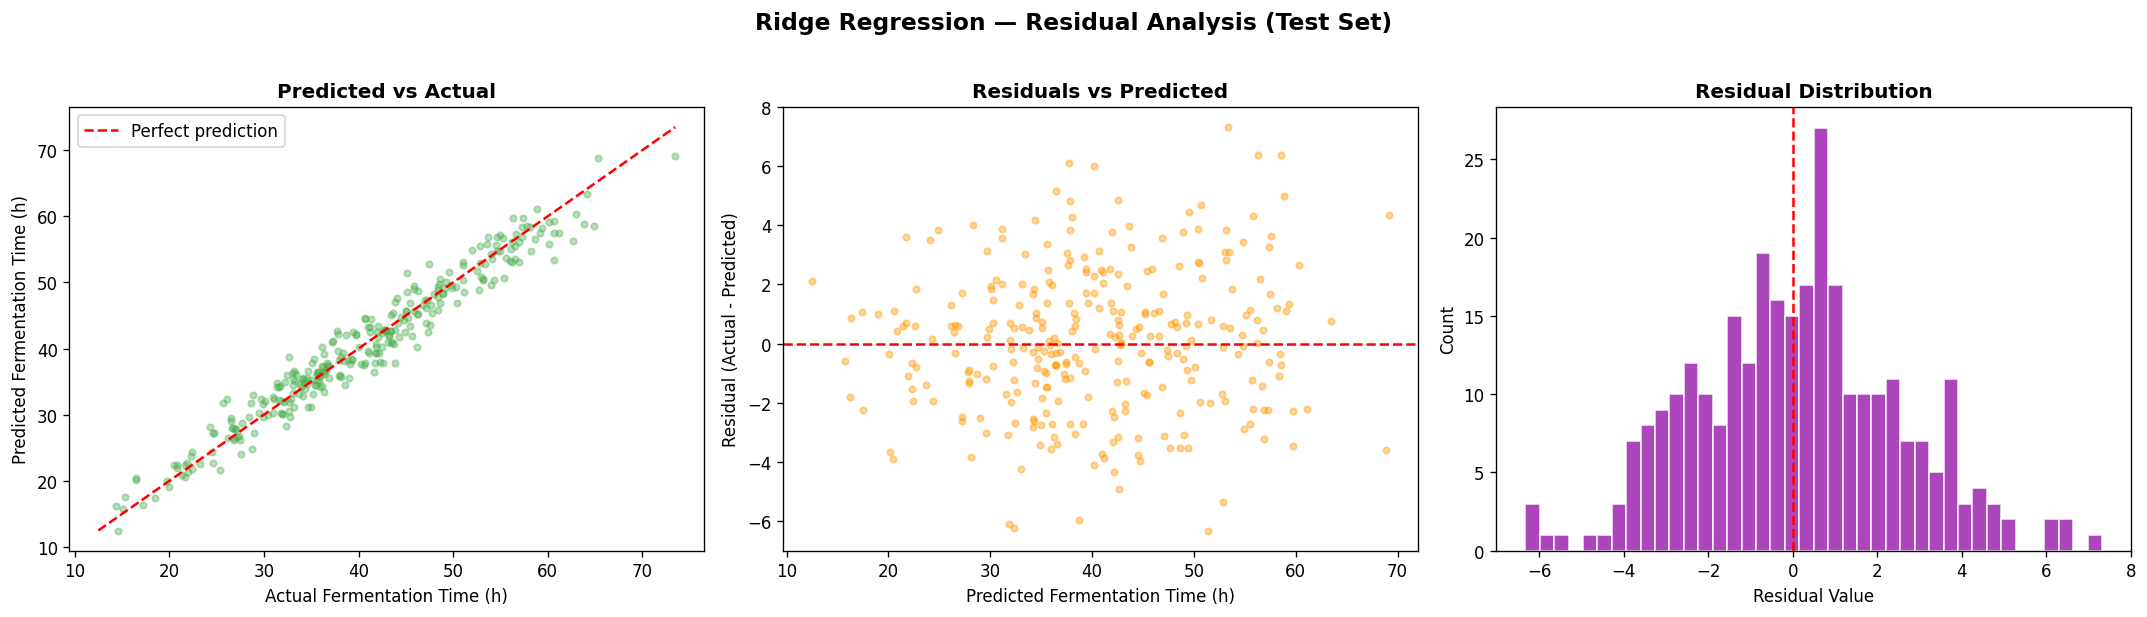

In [13]:
y_pred_final = ridge_cv.predict(X_test_proc)
residuals = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_final, alpha=0.4, color='#4CAF50', s=15)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Predicted vs Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Fermentation Time (h)')
axes[0].set_ylabel('Predicted Fermentation Time (h)')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(y_pred_final, residuals, alpha=0.4, color='#FF9800', s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Fermentation Time (h)')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# Residual distribution
axes[2].hist(residuals, bins=40, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[2].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Count')
axes[2].axvline(0, color='red', linestyle='--')

plt.suptitle('Ridge Regression — Residual Analysis (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/proj1_cheese_residuals.png', bbox_inches='tight')
plt.show()

### 7.3 Unseen Data Simulation — Production Robustness Check

In production, a model faces data it has never seen — from different batches, seasons, or slight process variations. Below we simulate a completely new batch of 500 fermentation observations (generated with a different random seed) and evaluate the trained model's performance. This is the ultimate test of generalization.

In [ ]:
# Generate completely unseen data with a different seed
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from data_generator import generate_cheese_dataset

unseen_df = generate_cheese_dataset(n=500, seed=999)

X_unseen = unseen_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_unseen = unseen_df[TARGET]

X_unseen_proc = preprocessor.transform(X_unseen)
y_unseen_pred = ridge_cv.predict(X_unseen_proc)

unseen_rmse = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
unseen_mae  = mean_absolute_error(y_unseen, y_unseen_pred)
unseen_r2   = r2_score(y_unseen, y_unseen_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted on unseen data
axes[0].scatter(y_unseen, y_unseen_pred, alpha=0.4, color='#E91E63', s=20, label=f'R² = {unseen_r2:.4f}')
lims = [min(y_unseen.min(), y_unseen_pred.min()), max(y_unseen.max(), y_unseen_pred.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Fit')
axes[0].set_title('Unseen Data: Predicted vs Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Fermentation Time (h)')
axes[0].set_ylabel('Predicted Fermentation Time (h)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = y_unseen.values - y_unseen_pred
axes[1].hist(errors, bins=30, color='#E91E63', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Prediction Error Distribution (Unseen)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Error (hours)')
axes[1].set_ylabel('Count')

# Performance comparison: Train vs Test vs Unseen
sets_labels = ['Training', 'Test', 'Unseen (new seed)']
r2_vals = [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred), unseen_r2]
rmse_vals = [np.sqrt(mean_squared_error(y_train, y_train_pred)), np.sqrt(mean_squared_error(y_test, y_test_pred)), unseen_rmse]
colors_bar = ['#2196F3', '#4CAF50', '#E91E63']
bars = axes[2].bar(sets_labels, r2_vals, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('R² Score: Train vs Test vs Unseen', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Production Robustness — Model Performance on Completely Unseen Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/proj1_cheese_unseen.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Unseen Data Performance:  RMSE = {unseen_rmse:.3f}h | MAE = {unseen_mae:.3f}h | R² = {unseen_r2:.4f}')
print(f'Test Set Performance:     RMSE = {test_rmse:.3f}h | R² = {r2_score(y_test, y_test_pred):.4f}')
print(f'\nConclusion: {"✅ Model generalizes well — stable across all splits" if abs(unseen_r2 - r2_score(y_test, y_test_pred)) < 0.05 else "⚠️ Performance gap detected — investigate further"}')

---
## 8. Key Takeaways

1. **OLS (Normal Equation)** provides the exact analytical solution but requires matrix inversion — computationally expensive for large feature sets.
2. **Gradient Descent** is the scalable alternative — it iteratively converges to the minimum and is the foundation of all deep learning optimizers.
3. **Ridge (L2)** is the go-to regularizer when you suspect multicollinearity. It shrinks all coefficients but keeps all features.
4. **Lasso (L1)** performs automatic feature selection by driving irrelevant feature coefficients to exactly zero.
5. **Elastic Net** is the practical choice when you have many correlated features and want both stability and sparsity.
6. **Never tune hyperparameters on the test set.** Use cross-validation on the training set, and reserve the test set for a single final evaluation.
